## On Paper: 

#### Diffusion Models

Thus $f(t)$ is defined as the probability of adoption at time $t$, or the fraction of the ultimate
potential which adopts the innovation at time $t$ and $F(t)$ is the fraction of the ultimate
potential which has adopted by time $t$.

The parameter p is called the coefficient of innovations and q the coefficient of imitation.

$$
\frac{f(t)}{1-F(t)}= p + q F(t)
$$


Solution, 

$$
F(t) = \frac{1-e^{-bt}}{1+ae^{-bt}}
$$


where, $a=\frac{q}{p}$, $b=p+q$


#### Substitution Models

$$
\frac{ds(t)}{dt} = ks(t)[1-s(t)]
$$

$$
s(t) = \frac{1}{1+e^{kt}}
$$

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 



In [78]:
t = np.linspace(0, 10, 100)

def compute_F(p, q, t):
    """ p and q have units of time! """
    a = q/p
    b = q+p
    return (1- np.exp(-b*t))/(1+a* np.exp(-b*t))

F = compute_F(p = 0.2, q = 0.9,  t=t)

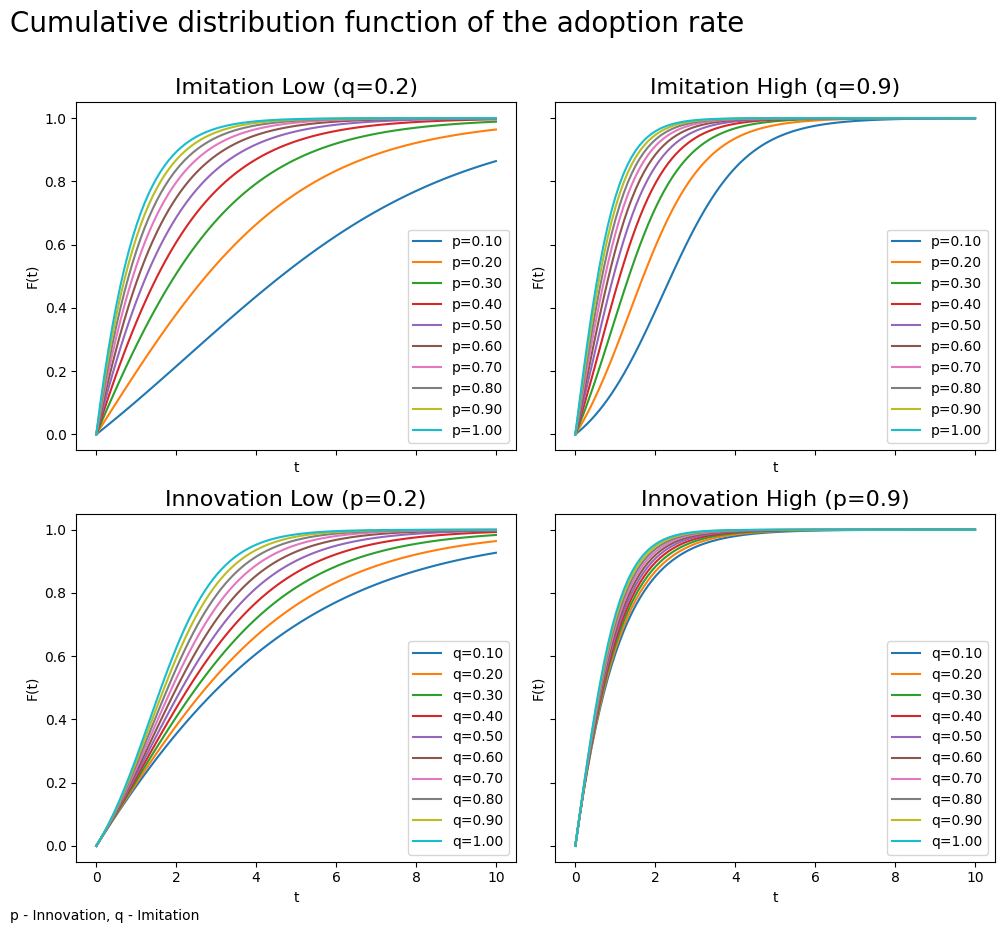

In [103]:
fig, axs = plt.subplots(figsize=(10,9), ncols=2, nrows=2, sharex=True, sharey=True)
fig.suptitle("Cumulative distribution function of the adoption rate", ha="left", va="bottom", x=0, y=0.98, size=20)
fig.text(x=0, y=0, s="p - Innovation, q - Imitation")
axs = axs.flatten()

ax = axs[0]
ax.set_title(f"Imitation Low (q=0.2)", fontsize=16)
for p in np.linspace(0,1, 11, )[1:]:
    F = compute_F(p = p, q = 0.2,  t=t)
    ax.plot(t, F, label=f"p={p:.2f}")
ax.legend()
ax.set_ylabel("F(t)")
ax.set_xlabel("t")

ax = axs[1]
ax.set_title(f"Imitation High (q=0.9)", fontsize=16)
for p in np.linspace(0,1, 11, )[1:]:
    F = compute_F(p = p, q = 0.9,  t=t)
    ax.plot(t, F, label=f"p={p:.2f}")
ax.legend()
ax.set_ylabel("F(t)")
ax.set_xlabel("t")

ax = axs[2]
ax.set_title(f"Innovation Low (p=0.2)", fontsize=16)
for q in np.linspace(0,1, 11, )[1:]:
    F = compute_F(p = 0.2, q = q,  t=t)
    ax.plot(t, F, label=f"q={q:.2f}")
ax.legend()
ax.set_ylabel("F(t)")
ax.set_xlabel("t")

ax = axs[3]
p = 0.9
ax.set_title(f"Innovation High (p=0.9)", fontsize=16)
for q in np.linspace(0,1, 11, )[1:]:
    F = compute_F(p = 0.9, q = q,  t=t)
    ax.plot(t, F, label=f"q={q:.2f}")
ax.legend()
ax.set_ylabel("F(t)")
ax.set_xlabel("t")

fig.tight_layout()

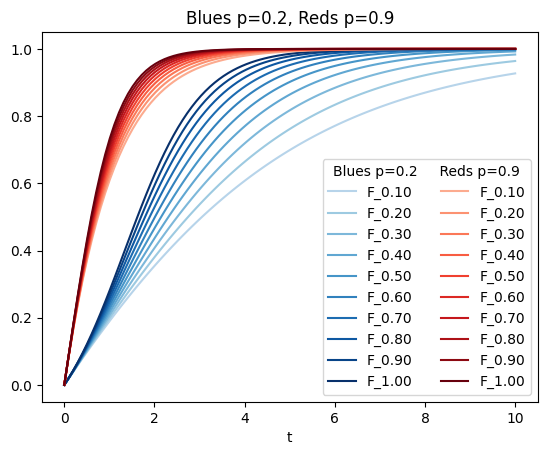

In [148]:
datas = [t]
labels = ["t"]
for q in np.linspace(0,1, 11, )[1:]:
    datas.append(compute_F(p = 0.2, q = q,  t=t))
    labels.append(f"F_{q:.2f}")
df_p2 = pd.DataFrame(datas, index=labels).T.set_index("t")


datas = [t]
labels = ["t"]
for q in np.linspace(0,1, 11, )[1:]:
    datas.append(compute_F(p = 0.9, q = q,  t=t))
    labels.append(f"F_{q:.2f}")
df_p9 = pd.DataFrame(datas, index=labels).T.set_index("t")


fig, ax = plt.subplots() 
colors = plt.cm.Blues(np.linspace(0.3, 1.0, df.shape[1]))
ax = df_p2.plot(ax=ax, color=colors)

colors = plt.cm.Reds(np.linspace(0.3, 1.0, df.shape[1]))
ax = df_p9.plot(ax=ax, color=colors)
ax.legend(ncols=2, title="Blues p=0.2     Reds p=0.9")

_ = ax.set_title("Blues p=0.2, Reds p=0.9")

### Hipothesis:

1. We assume that once an application incorporates some level of the new technology, it does not revert to earlier technologies during the relevant period of time.
2. In the case where adopters buy multiple units of a new innovation, sales will consist of the number of units purchased per user times the number of users.
3. The average rate of consumption per time period approaches a constant. More specifically, let the usage rates associated with applications be independently and indentically distributed with a constant overall mean rate. (The arguent for the constancy of this rate is based on the fact that, as the number of consuming units gets large, the change in the average amount consumed will be little affected by the inclusion of an incremental user.)
4. The number of uses of a given device changes over time. The device may have been invented to go into a particular product or solve la particular problem. It may also have uses which are not imagined until it exists.
5. A device may perform better than something currently available. The uses of some generations of innovations are growing in number, however rapid its growth appears, each device must have some upper limit on its applicability, and we assume that limit to be constant. We assume also that the rate of growth in applications incorporating a given device is related to the number of applications already existing and the number of potential applications yet to be made.


Model development

Let, 

- $M$ - be the upper limit of the number of applications.
- $r$ - the rate at cwhich an average application consumes the output of interest.
- $m = Mr$ - the upper limit on sales per time period.
- $S(t)$ - Sales
- $F(t)$ - Cumulative distribution function of the adoption rate.


$$S(t) = mF(t)$$

$$
S_1(t) = F_1(t)m1 - F_2(t-\tau_2)F_1(t)m_1=F_1(t)m1[1-F_2(t-\tau_2)
$$

$$
S_2(T)=F_2(t-\tau_2)[m_2+F_1(t)m_1] \text{ for }t>\tau_2
$$


If we relax the assumption that the adoption process differs by generations, we can
write pi = p and qi = q for all i. This assumption has a certain plausibility in that for a
given technology class the behavioral processes for the adoption of advancing generations 
could be expected to be similar. If the assumptionis approximately correct, the
number of parameters to be estimated will be drastically reduced. For example, if F has
k parameters and there are n generations, there will be kn + n parameters to estimate,
but if the k parameters of F are the same for each generation the number of parameters
to estimate will be k + n. The very strong assumption that p and q are constant across
equations should be easily falsifiable on the basis of model fit: If the pi and qi are really
different for different i, it should be difficult to obtain reasonable fits to the empirical
data and reasonable forecasts using the simpler model.


General expresion of the model: 

$$
S_n(t)=\Sigma_{k=1}^{n}G_{k,n} [1-F(t-\tau_n)]
$$

where, 
$$
G_{k,n}=_k \Pi_{i=k}^{n}F(t-\tau_i)]
$$

In [247]:
import math
from typing import Callable, Sequence

# def G_kn(k: int, n: int, t: float, tau: Sequence[float],
#          F: Callable[[float, float, float], float],
#          p: float, q: float) -> float:
#     """
#     Compute G_{k,n} = product_{i=k}^n F(t - tau_i)
#     """
#     prod = 1.0
#     for i in range(k-1, n):  # k,n are 1-based; Python is 0-based
#         prod *= F(t - tau[i], p, q)
#     return prod


# def S_n(n: int, t: float, tau: Sequence[float],
#         F: Callable[[float, float, float], float],
#         p: float, q: float) -> float:
#     """
#     Compute S_n(t) = sum_{k=1}^n G_{k,n} * [1 - F(t - tau_n)]
#     """
#     Fn = F(t - tau[n-1], p, q)
#     factor = 1.0 - Fn

#     total = 0.0
#     for k in range(1, n+1):
#         total += G_kn(k, n, t, tau, F, p, q) * factor

#     return total

def F(x, p, q):
    """
    x = t - tau_i
    p, q have units of time
    Vectorized in x (scalar or numpy array).
    F(x)=0 for x<0.
    """
    # x = np.asarray(x)
    a = q / p
    b = q + p
    out = np.zeros_like(x, dtype=float)
    mask = x >= 0
    xm = x[mask]
    out[mask] = (1.0 - np.exp(-b * xm)) / (1.0 + a * np.exp(-b * xm))
    return out

def G_kn(k, n, t, tau, m, F, p, q):
    prod = 1.0
    for i in range(k-1, n):
        prod *= F(t - tau[i], p, q)
    return m[n-1] * prod


def S_n_fast(n, t, tau, m, F, p, q):
    """
    tau: array dim M (number of devices)
    m: array dim M (number of devices)
    """
    assert (n <= len(tau)) and (len(tau)==len(m)), "Check n <= lent(tau) and len(tau)==len(m)"
    Fn = F(t - tau[n-1], p, q)
    factor = 1.0 - Fn

    total = 0.0
    for k in range(1, n+1):
        total += G_kn(k, n, t, tau, m, F, p, q) * factor
        
    return total

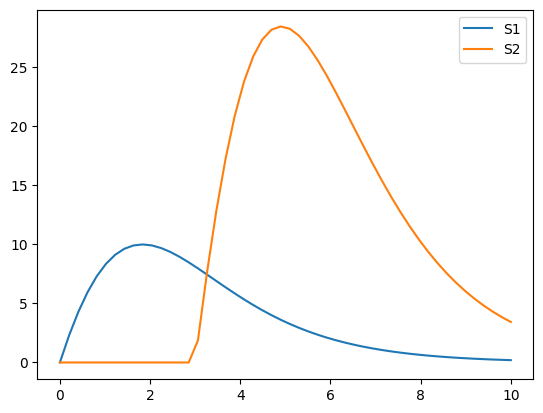

In [254]:
t = np.linspace(0, 10)
n = 3
f = F(t, p0, q0)
tau = [0, 3]
m = [40, 60]

plt.plot(t, S_n_fast(1, t, tau, m, F, p=p0, q=q0), label="S1")
plt.plot(t, S_n_fast(2, t, tau, m, F, p=p0, q=q0), label="S2")
plt.legend()

In [149]:

p0 = 0.3
q0 = 0.5
m1 = 700
m2 = 300

tau_2 = 3

F1 = compute_F(p = p0, q = q0,  t=t)

F2 = compute_F(p = p0, q = q0,  t=t-tau_2)
F2 = np.where(F2<0,0,F2)


# S1 and S2
S1 = m1*F1*(1-F2)
S2 = F2*(m2+F1*m1)



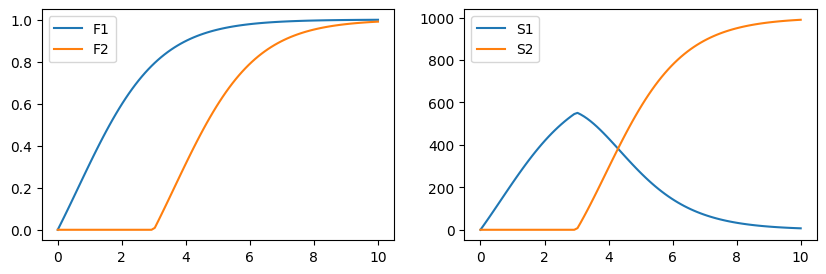

In [150]:
fig, axs = plt.subplots(figsize=(10,3), ncols=2)
axs = axs.flatten()

ax = axs[0]
ax.plot(t, F1, label="F1")
ax.plot(t, F2, label="F2")
ax.legend()

ax = axs[1]
ax.plot(t, S1, label="S1")
ax.plot(t, S2, label="S2")
ax.legend()

In [154]:

p0 = 0.3
q0 = 0.3

M = 2500
m1 = M*0.5
m2 = M*0.3
m3 = M*0.2

tau_2 = 3
tau_3 = 7

F1 = compute_F(p = p0, q = q0,  t=t)

F2 = compute_F(p = p0, q = q0,  t=t-tau_2)
F2 = np.where(F2<0,0,F2)

F3 = compute_F(p = p0, q = q0,  t=t-tau_3)
F3 = np.where(F3<0,0,F3)


# S1, S2, S3
S1 = F1*(m1*(1-F2*F3))
S2 = F2*(m1*F1 + m2*(1-F3))
S3 = F3*(m1*F1 + m2*F2 + m3)


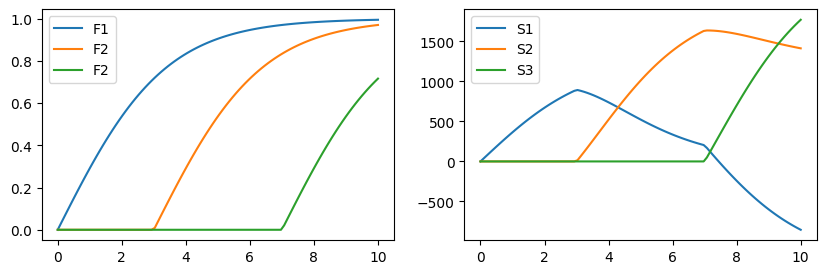

In [155]:
fig, axs = plt.subplots(figsize=(10,3), ncols=2)
axs = axs.flatten()

ax = axs[0]
ax.plot(t, F1, label="F1")
ax.plot(t, F2, label="F2")
ax.plot(t, F3, label="F2")
ax.legend()

ax = axs[1]
ax.plot(t, S1, label="S1")
ax.plot(t, S2, label="S2")
ax.plot(t, S3, label="S3")
ax.legend()

## Model Fitting 

In [ ]:
# https://github.com/marmiskarian/bassmodeldiffusion/tree/main


In [203]:
data = pd.read_csv("./data/mobile_sales_data.csv")
data["Dispatch Date"] = pd.to_datetime(data["Dispatch Date"])
                                       
print(data.columns)
scols = [
    'Product', 'Brand', 'Price','Product Code',
       'Inward Date', 'Dispatch Date', 'Quantity Sold', 'Customer Name',
       'Customer Location', 'Region', 'Core Specification',
       'Processor Specification', 'RAM', 'ROM', 'SSD']
data[scols]

Index(['Product', 'Brand', 'Product Code', 'Product Specification', 'Price',
       'Inward Date', 'Dispatch Date', 'Quantity Sold', 'Customer Name',
       'Customer Location', 'Region', 'Core Specification',
       'Processor Specification', 'RAM', 'ROM', 'SSD'],
      dtype='object')


,Product,Brand,Price,Product Code,Inward Date,Dispatch Date,Quantity Sold,Customer Name,Customer Location,Region,Core Specification,Processor Specification,RAM,ROM,SSD
0,Mobile Phone,Motorola,78570,88EB4558,2023-08-02,2023-08-03,6,William Hess,South Kelsey,Central,NaN,Snapdragon 7 Gen,12GB,128GB,NaN
1,Laptop,Oppo,44613,416DFEEB,2023-10-03,2023-10-06,1,Larry Smith,North Lisa,South,Ryzen 5,Ryzen 5,8GB,512GB,256GB
2,Mobile Phone,Samsung,159826,9F975B08,2025-03-19,2025-03-20,5,Leah Copeland,South Todd,Central,NaN,MediaTek Dimensity,8GB,256GB,NaN
3,Laptop,Sony,20911,73D2A7CC,2024-02-06,2024-03-27,1,Dan Kirby,New Jordanmouth,South,i7,i7,12GB,64GB,2TB
4,Laptop,Microsoft,69832,CCE0B80D,2023-08-10,2023-09-10,4,Dean Martin,Keithton,East,i7,i7,8GB,128GB,2TB
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,Laptop,Motorola,170385,8C187637,2024-03-02,2024-04-11,6,Sara Gomez,Sylviatown,North,i3,i3,16GB,512GB,2TB
49996,Laptop,HP,193133,0DA9E4D3,2025-01-19,2025-01-20,4,Raymond Clark,Chrismouth,West,i7,i7,8GB,1TB,512GB
49997,Laptop,Toshiba,66502,CAD89A93,2024-01-16,2024-03-05,6,Joseph Martin,Huntfurt,North,i5,i5,4GB,64GB,2TB
49998,Mobile Phone,Lenovo,158883,78566C17,2023-05-15,2023-05-25,2,Gabrielle Barnett,Heidiberg,North,NaN,Snapdragon 7s,12GB,1TB,NaN


In [209]:
qdata = (
    data
    .groupby([
        pd.Grouper(key="Dispatch Date", freq="QE"),
        "Core Specification"
    ])["Quantity Sold"].agg(
        sales = "count", demand="sum").reset_index()    
)
qdata["avg_demand"] = qdata['demand']/qdata['sales']

In [210]:
qdata

,Dispatch Date,Core Specification,sales,demand,avg_demand
0,2023-03-31,Ryzen 3,6,40,6.666667
1,2023-03-31,Ryzen 5,3,15,5.000000
2,2023-03-31,Ryzen 7,4,30,7.500000
3,2023-03-31,Ryzen 9,2,11,5.500000
4,2023-03-31,i3,6,42,7.000000
...,...,...,...,...,...
75,2025-06-30,Ryzen 9,85,455,5.352941
76,2025-06-30,i3,85,437,5.141176
77,2025-06-30,i5,101,560,5.544554
78,2025-06-30,i7,71,375,5.281690


In [211]:
cond = qdata['Core Specification'].str.contains('i5')
qdata[cond]

,Dispatch Date,Core Specification,sales,demand,avg_demand
5,2023-03-31,i5,3,25,8.333333
13,2023-06-30,i5,319,1675,5.250784
21,2023-09-30,i5,381,1986,5.212598
29,2023-12-31,i5,444,2482,5.590090
37,2024-03-31,i5,425,2364,5.562353
45,2024-06-30,i5,395,2211,5.597468
53,2024-09-30,i5,375,2037,5.432000
61,2024-12-31,i5,382,2168,5.675393
69,2025-03-31,i5,390,2105,5.397436
77,2025-06-30,i5,101,560,5.544554


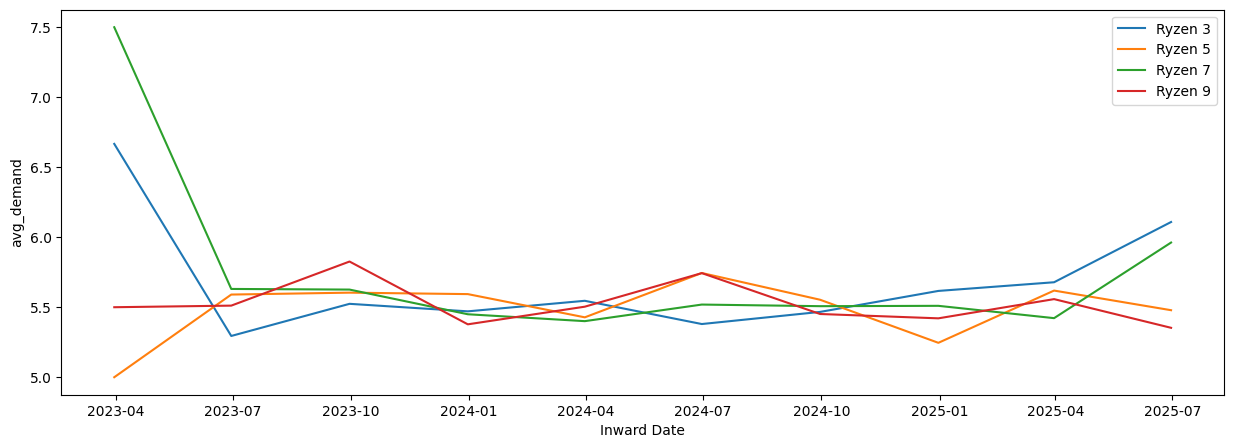

In [214]:
cond = qdata['Core Specification'].str.contains('y')

fig, ax = plt.subplots(figsize=(15,5))

for core_spec, g in qdata[cond].groupby("Core Specification"):
    ax.plot(
        g["Dispatch Date"],
        g["avg_demand"],
        label=core_spec
    )

ax.set_xlabel("Inward Date")
ax.set_ylabel("avg_demand")
ax.legend()

In [170]:
data[['Core Specification']].value_counts()

Core Specification
i5                    3215
Ryzen 3               3176
i9                    3146
i3                    3143
Ryzen 7               3135
i7                    3105
Ryzen 5               3050
Ryzen 9               3047
Name: count, dtype: int64

In [ ]:
from scipy.optimize import curve_fit

def c_t(x, p, q, m):
    return (p+(q/m)*(x))*(m-x)
popt, pcov = curve_fit(c_t, data.cum_sum[0:11], data.revenues[1:12])